#GEOL0069 Final Project Notebook: Physics-Informed Deep Learning for Efficient Extraction of Biophysical Parameter Time Series


This notebook includes the training and validation (on both synthetic and field data) of the ARC-VAE model, a differentiable, physics-informed variational autoencoder framework designed to extract continuous biophysical parameter trajectories from irregular satellite observation profiles.

The code is run on Google Colab using an NVIDIA T4 GPU. Model code is placed in an 01_ARC-VAE folder at the location '/content/drive/MyDrive/01_ARC-VAE'; cloning of the ARC repository is also done into this folder.

In [ ]:
#Mounting google drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
!pip install pynndescent jax jaxlib scipy tqdm -q

Mounted at /content/drive


In [ ]:
#%cd /content/drive/MyDrive/01_ARC-VAE #cloning ARC if needed
#!git clone https://github.com/MarcYin/ARC.git

In [ ]:
#Checking ARC has been successfully cloned
import os
base = '/content/drive/MyDrive/01_ARC-VAE'
print("ARC exists:   ", os.path.exists(f'{base}/ARC'))
print("US_001 size:  ", os.path.getsize(f'{base}/ARC/arc/data/US_001.npz'), "bytes")

ARC exists:    True
US_001 size:   41386 bytes


In [ ]:
#Extracting zip of arc-vae .py files (during training, these were stored in Google Drive in zip format)
import zipfile, shutil
base = '/content/drive/MyDrive/01_ARC-VAE'
shutil.rmtree(f'{base}/arc_vae', ignore_errors=True)
with zipfile.ZipFile(f'{base}/arc_vae_v8.zip', 'r') as z:
    z.extractall(base)

# Model Training

The following cell allows training of the ARC-VAE architecture on 200,000 synthetic, cloud-masked, and noise-corrupted Sentinel-2 time series. Training runs for 50 epochs. In the first stage (20 epochs), β=0, followed by linear annealing from 0 to 0.3 to gradually regularise the posterior towards the prior distribution of the (p,h) parameters. We track the approximate carbon usage of the data generation and training procedure using CodeCarbon.

In [ ]:
"""
ARC-VAE Training
"""

# CodeCarbon installation
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "codecarbon", "-q"],
               check=True)

# Imports
import time
import math
import os
from datetime import timedelta
from pathlib import Path

import torch
from torch.utils.data import DataLoader

BASE = '/content/drive/MyDrive/01_ARC-VAE'
sys.path.insert(0, f'{BASE}/ARC')
sys.path.insert(0, f'{BASE}/arc_vae')

from synthetic_dataloader import GermanyMaizeDataset
from training import ARCVAE, train

# Configuration
CFG = dict(
    n_train      = 200_000, # We allocate 200,000 synthetic items for training
    n_val        = 10_000,  # 10,000 validation samples for evaluation
    batch_size   = 128,     # Define the data sequence sizing limit per gradient step
    n_epochs_s1  = 20,      # 20 initial epochs (first phase of training, beta = 0)
    n_epochs_s2  = 30,      # 30 subsequent epochs (second phase, beta linearly annealed to 0.3)
    beta_target  = 0.3,     # Define target KL scale parameter constraint limit
    lambda_sup   = 10.0,    # Set the weight of the supervised parameter loss factor (penalises deviation from original p,h parameters that generate a given S2 time series)
    lr           = 1e-4,    # Baseline learning rate
    d_model      = 128,     # Set hidden transformer embedding vector size
    n_layers     = 4,       # Configure total stacked transformer layers count
    n_heads      = 4,       # Define self-attention layer parallel split count
    n_queries    = 4,       # Set parameter pooling query dimension tracking counts
    d_ff         = 256,     # Set dense layer inner expansion state dimensions
    dropout      = 0.1,     # Structural node drop evaluation rate
    seed         = 42,      # Set seed
    log_every    = 100,     # Set iteration step intervals for print logging
    crop_type    = "maize", # Set crop archetype from ARC model (Yin et al., 2025)
)

device = "cuda" if torch.cuda.is_available() else "cpu" #route to GPU
torch.manual_seed(CFG["seed"])

# Info on GPU (approxiimately 50W power usage for T4)
if device == "cuda":
    gpu_name = torch.cuda.get_device_name(0)
    GPU_POWER_W = {"T4": 50, "V100": 200, "A100": 250, "L4": 120}
    gpu_power_w = next(
        (w for k, w in GPU_POWER_W.items() if k in gpu_name), 80)
    print(f"GPU: {gpu_name}  (estimated avg power: {gpu_power_w}W)")
else:
    gpu_name    = "CPU"
    gpu_power_w = 35  # typical Colab CPU-only power draw (W)
    print("Running on CPU")

# Output directory
# Construct a unique runtime execution directory identifier string to allow tracking
from datetime import datetime
run_name = (f"maize_d{CFG['d_model']}_L{CFG['n_layers']}"
            f"_e{CFG['n_epochs_s1']}+{CFG['n_epochs_s2']}"
            f"_sup{CFG['lambda_sup']}"
            f"_{datetime.now().strftime('%Y%m%d_%H%M')}")
out_dir = Path(f"{BASE}/outputs/{run_name}")
out_dir.mkdir(parents=True, exist_ok=True) #create output directory
print(f"Output dir: {out_dir}\n")

# Data generation
print(f"Generating {CFG['n_train']:,} training samples")
t0_data = time.time()
#create training dataset
train_ds = GermanyMaizeDataset(
    n_samples=CFG["n_train"], seed=CFG["seed"],
    crop_type=CFG["crop_type"])
#create validation data
val_ds = GermanyMaizeDataset(
    n_samples=CFG["n_val"], seed=CFG["seed"] + 99999,
    crop_type=CFG["crop_type"])
t_data = time.time() - t0_data
print(f"Data generation: {timedelta(seconds=int(t_data))}\n")

# Construct data loader for batching training metrics
train_loader = DataLoader(
    train_ds, batch_size=CFG["batch_size"],
    shuffle=True, num_workers=0,
    pin_memory=(device == "cuda"))
# Construct data loader for batching validation metrics
val_loader = DataLoader(
    val_ds, batch_size=CFG["batch_size"],
    shuffle=False, num_workers=0,
    pin_memory=(device == "cuda"))

# Model
#Construct main combined autoencoder
model = ARCVAE(
    crop_type = CFG["crop_type"],
    d_model   = CFG["d_model"],
    n_layers  = CFG["n_layers"],
    n_heads   = CFG["n_heads"],
    n_queries = CFG["n_queries"],
    d_ff      = CFG["d_ff"],
    dropout   = CFG["dropout"],
)
n_enc = sum(p.numel() for p in model.encoder.parameters() if p.requires_grad)
print(f"Encoder parameters (trainable): {n_enc:,}")
print(f"lambda_sup = {CFG['lambda_sup']}  (supervised auxiliary loss ON)\n") #adding supervised loss

# start CodeCarbon tracking
try:
    from codecarbon import EmissionsTracker
    tracker = EmissionsTracker(
        project_name     = "arc_vae_run5",
        output_dir       = str(out_dir),
        log_level        = "error",   # avoid long codecarbon output
        save_to_file     = True,
        tracking_mode    = "process",
    )
    tracker.start()
    codecarbon_available = True
    print("CodeCarbon tracking: ON")
except Exception as e:
    tracker = None
    codecarbon_available = False
    print(f"CodeCarbon not available ({e}), using manual estimate")

# Training
print(f"Starting training: {CFG['n_epochs_s1']+CFG['n_epochs_s2']} epochs")
print(f"  Stage 1 (β=0):    epochs 1–{CFG['n_epochs_s1']}")
print(f"  Stage 2 (β→0.3):  epochs {CFG['n_epochs_s1']+1}–"
      f"{CFG['n_epochs_s1']+CFG['n_epochs_s2']}")

t_train_start = time.time() #start training timer

history = train(
    model           = model,
    train_loader    = train_loader,
    val_loader      = val_loader,
    n_epochs_s1     = CFG["n_epochs_s1"],
    n_epochs_s2     = CFG["n_epochs_s2"],
    beta_target     = CFG["beta_target"],
    lambda_sup      = CFG["lambda_sup"],
    lr              = CFG["lr"],
    device          = device,
    log_every       = CFG["log_every"],
    checkpoint_dir  = str(out_dir),
)

t_train_end  = time.time() #end training timer
t_train_secs = t_train_end - t_train_start

# stop CodeCarbon tracker
codecarbon_kg = None
if codecarbon_available and tracker is not None:
    try:
        codecarbon_kg = tracker.stop()   # returns kg CO₂eq
    except Exception:
        codecarbon_kg = None

# We also crudely estimate carbon usage for comparison to CodeCarbon findings, using the following approach and data:
# Energy = power (W) × time (h) / 1000, gives kWh
# Carbon = kWh × intensity (gCO₂eq/kWh) / 1000, gives kg CO₂eq
#
# Carbon intensities used:
#   Global average:  ~475 gCO₂eq/kWh  (IEA 2023)
#   But to note that Google cloud platform offsets emissions through power purchase agreements

energy_kwh       = (gpu_power_w * t_train_secs / 3600) / 1000
carbon_global_g  = energy_kwh * 475    # gCO₂eq, global average grid
carbon_global_kg = carbon_global_g / 1000

# Make report
hours   = int(t_train_secs // 3600)
minutes = int((t_train_secs % 3600) // 60)
seconds = int(t_train_secs % 60)

print(f"Training complete.")
print(f"\nTiming:")
print(f"  Data generation:  {timedelta(seconds=int(t_data))}")
print(f"  Training:         {hours:02d}h {minutes:02d}m {seconds:02d}s  "
      f"({t_train_secs:.0f}s total)")
print(f"  Per epoch:        {t_train_secs/(CFG['n_epochs_s1']+CFG['n_epochs_s2']):.1f}s")
print(f"\nFinal losses:")
print(f"  val_rec:   {history['val_rec'][-1]:.4f}")
print(f"  val_kl:    {history['val_kl'][-1]:.4f}")
if "train_sup" in history and history["train_sup"]:
    print(f"  train_sup: {history['train_sup'][-1]:.6f}  "
          f"(was {history['train_sup'][0]:.6f} at epoch 1)")
print(f"\nCarbon cost (training only):")
print(f"  GPU:              {gpu_name}  (~{gpu_power_w}W avg)")
print(f"  Energy consumed:  {energy_kwh*1000:.1f} Wh  ({energy_kwh:.4f} kWh)")
if codecarbon_kg is not None:
    print(f"  CodeCarbon est:   {codecarbon_kg*1000:.2f} gCO₂eq  "
          f"({codecarbon_kg:.5f} kg)")
print(f"  Conservative est: {carbon_global_g:.2f} gCO₂eq  "
      f"({carbon_global_kg:.5f} kg)  [global avg grid, 475 gCO₂/kWh]")
print(f"\nCheckpoint saved to: {out_dir}/checkpoint_best.pt")

# Save timing + carbon to JSON
import json
report = {
    "run_name":         run_name,
    "config":           CFG,
    "device":           device,
    "gpu_name":         gpu_name,
    "t_data_s":         round(t_data, 1),
    "t_train_s":        round(t_train_secs, 1),
    "t_per_epoch_s":    round(t_train_secs /
                              (CFG["n_epochs_s1"]+CFG["n_epochs_s2"]), 1),
    "energy_wh":        round(energy_kwh*1000, 2),
    "carbon_global_g":  round(carbon_global_g, 3),
    "carbon_codecarbon_g": round(codecarbon_kg*1000, 3) if codecarbon_kg else None,
    "final_val_rec":    round(history["val_rec"][-1], 4),
    "final_val_kl":     round(history["val_kl"][-1], 4),
    "final_train_sup":  round(history["train_sup"][-1], 6)
                        if "train_sup" in history and history["train_sup"]
                        else None,
}
with open(out_dir / "training_report.json", "w") as f:
    json.dump(report, f, indent=2)
print(f"Report saved to: {out_dir}/training_report.json")

GPU: Tesla T4  (estimated avg power: 50W)
Output dir: /content/drive/MyDrive/01_ARC-VAE/outputs/maize_d128_L4_e20+30_sup10.0_20260518_1637

Generating 200,000 training samples...
Generating 200,000 synthetic samples...


Predicting S2 reflectance: 100%|██████████| 300/300 [00:01<00:00, 156.45slice/s]


Done.
Generating 10,000 synthetic samples...


Predicting S2 reflectance: 100%|██████████| 300/300 [00:00<00:00, 305.37slice/s]


Done.
Data generation: 0:18:34

Encoder parameters (trainable): 619,414
lambda_sup = 10.0  (supervised auxiliary loss ON)



[codecarbon WARNING @ 16:56:28] Multiple instances of codecarbon are allowed to run at the same time.


CodeCarbon tracking: ON

Starting training: 50 epochs
  Stage 1 (β=0):    epochs 1–20
  Stage 2 (β→0.3):  epochs 21–50

  Epoch   1/50  batch    0  β=0.000  rec=151.0011  kl=28.3985  sup=0.1366
  Epoch   1/50  batch  100  β=0.000  rec=24.9923  kl=44.5925  sup=0.1430
  Epoch   1/50  batch  200  β=0.000  rec=21.8981  kl=50.9550  sup=0.0969
  Epoch   1/50  batch  300  β=0.000  rec=18.2818  kl=53.3581  sup=0.0913
  Epoch   1/50  batch  400  β=0.000  rec=17.2766  kl=54.1283  sup=0.0840
  Epoch   1/50  batch  500  β=0.000  rec=16.2231  kl=53.3325  sup=0.0879
  Epoch   1/50  batch  600  β=0.000  rec=16.6770  kl=55.0958  sup=0.0758
  Epoch   1/50  batch  700  β=0.000  rec=13.3945  kl=54.9894  sup=0.0786
  Epoch   1/50  batch  800  β=0.000  rec=19.4486  kl=55.5649  sup=0.0847
  Epoch   1/50  batch  900  β=0.000  rec=15.7218  kl=56.1246  sup=0.0795
  Epoch   1/50  batch 1000  β=0.000  rec=13.9839  kl=54.4476  sup=0.0709
  Epoch   1/50  batch 1100  β=0.000  rec=15.2232  kl=55.3193  sup=0.0756
  E

## Validation on Synthetic Data

This cell benchmarks performance of the ARC-VAE against ARC in terms of (p,h) latent variable reconstruction and biophysical parameter time series reconstruction (via plots, as well as $R^2$ and RMSE) on synthetic test data. Here, we also track carbon usage during inference for both models.

Device: Tesla T4  (~50W avg)
Encoder loaded  (619,414 params)

Generating 32 test samples


Predicting S2 reflectance: 100%|██████████| 300/300 [00:02<00:00, 131.58slice/s]
[codecarbon WARNING @ 12:01:04] Multiple instances of codecarbon are allowed to run at the same time.


Got 32 samples.

Running encoder.
Encoder done.  Total: 0.04s  (1.36 ms/pixel)

Running ARC-KNN on 32 pixels  (library=131,072)...


Predicting S2 reflectance: 100%|██████████| 300/300 [00:25<00:00, 11.65slice/s]


  KNN  20/32  |  elapsed 0:33:25  |  remaining ~0:20:03


Predicting S2 reflectance: 100%|██████████| 300/300 [00:25<00:00, 11.89slice/s]



KNN done.  Total: 0:52:44  (98.9 s/pixel)


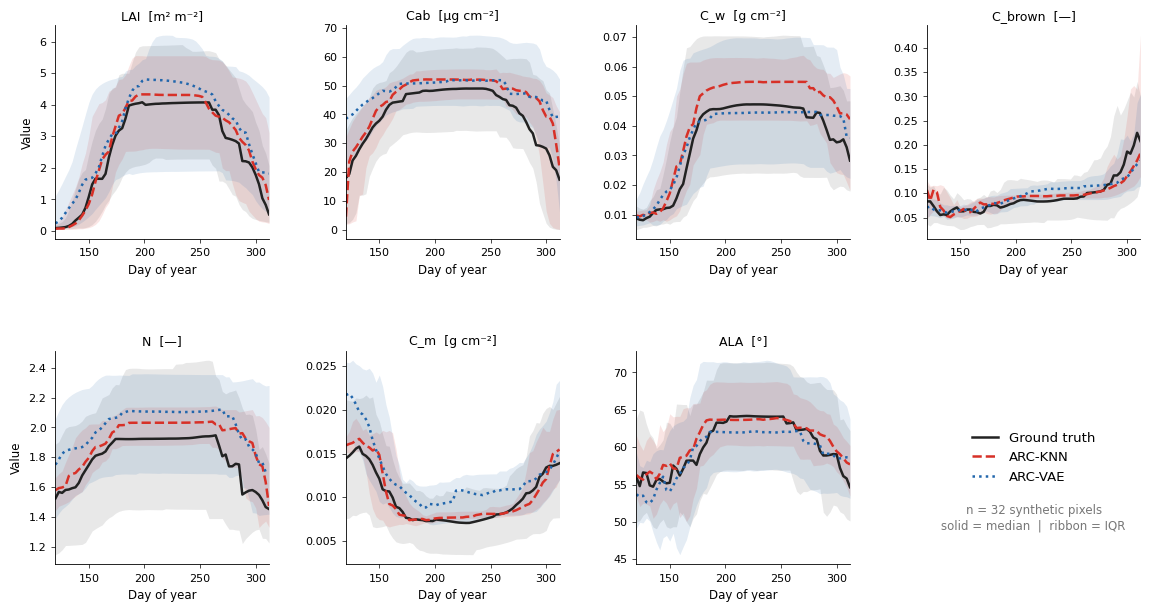


All results saved to /content/drive/MyDrive/01_ARC-VAE/outputs/arc_knn_run5/


In [ ]:
import subprocess, sys #import native system execution and subprocess management modules
subprocess.run([sys.executable, "-m", "pip", "install", "codecarbon", "-q"],
               check=True) #installing code carbon into instance

#imports
import os, time, json, numpy as np, torch, matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from pathlib import Path
from datetime import timedelta, datetime
import importlib.util
cc_available = True
cc_vae_kg = None
cc_knn_kg = None

BASE = '/content/drive/MyDrive/01_ARC-VAE' #define base storage directory
sys.path.insert(0, f'{BASE}/ARC') #append ARC
sys.path.insert(0, f'{BASE}/arc_vae') #append ARC-VAE

CKPT    = (f'{BASE}/outputs/'
           'maize_d128_L4_e20+30_sup10.0_20260518_1637/checkpoint_best.pt') #load checkpoint from trained ARC-VAE with lowest ELBO
OUT_DIR = f'{BASE}/outputs/arc_knn_run5' #define output directory
os.makedirs(OUT_DIR, exist_ok=True) #create output directory

N_SAMPLES = 32 #set subset size of synthetic pixel sequences for evaluation
N_LIBRARY = 131072 #set total size of Sobol reference library for each KNN lookup search step

DOYS_NP         = np.arange(130, 310, 8) #build timeline sequence array representing valid satellite acquisition days
START_OF_SEASON = 135 #set initial planting
GROWTH_SEA_LEN  = 145 #set season length
T               = len(DOYS_NP) #extract total count of active observation points
SZA = np.full(T, 35.); VZA = np.full(T, 5.); RAA = np.full(T, 120.) #building sensor viewing angle arrays
ANGS  = (SZA, VZA, RAA) #make tuple of angle arrays
PDOYS = np.arange(120, 315, 3) #create daily timeline vector for computing continuous canopy profiles

C_TRUE = '#222222'; C_KNN = '#d73027'; C_ENC = '#2166ac' #colours for ground truth, KNN, and encoder for plotting later

#plotting styles
plt.rcParams.update({
    'font.family':'DejaVu Sans','font.size':9,'font.weight':'normal',
    'axes.titleweight':'normal','axes.spines.top':False,
    'axes.spines.right':False,'axes.linewidth':0.6,
    'xtick.major.size':3,'ytick.major.size':3,
    'xtick.major.width':0.5,'ytick.major.width':0.5,'axes.grid':False,
    'legend.frameon':False,
})

# Define GPU info as in training script
device = "cuda" if torch.cuda.is_available() else "cpu"
if device == "cuda":
    gpu_name = torch.cuda.get_device_name(0)
    GPU_POWER_W = {"T4":50,"V100":200,"A100":250,"L4":120}
    gpu_power_w = next((w for k,w in GPU_POWER_W.items() if k in gpu_name), 80)
else:
    gpu_name = "CPU"; gpu_power_w = 35
print(f"Device: {gpu_name}  (~{gpu_power_w}W avg)")

# Load encoder
from encoder import ARCVAEEncoder
from archetype_decoder import ARCDecoder, double_logistic

encoder = ARCVAEEncoder(d_model=128, n_layers=4, n_heads=4) #load encoder framework using config parameters
ckpt_d  = torch.load(CKPT, map_location='cpu') #load checkpoint file parameters
fs      = ckpt_d.get('model_state', ckpt_d) #extract model coefficients
encoder.load_state_dict({k[len('encoder.'):]: v
    for k, v in fs.items() if k.startswith('encoder.')})
encoder.eval() #shift encoder into fixed evaluation mode
decoder = ARCDecoder(crop_type='maize') #load ARC
decoder.eval() #shift ARC into fixed evaluation mode
print(f"Encoder loaded  ({sum(p.numel() for p in encoder.parameters()):,} params)") #report number of parameters

# Set ARC components
_p = Path(f'{BASE}/ARC/arc/arc_sample_generator.py') #point to ARC
_s = importlib.util.spec_from_file_location('arc_sg', _p)
_m = importlib.util.module_from_spec(_s); _s.loader.exec_module(_m) #make separate runtime module
generate_arc_refs = _m.generate_arc_refs
from arc.approximate_KNN_search import get_neighbours #import KNN search function for ARC

# start CodeCarbon
from codecarbon import EmissionsTracker

# Generate synthetic data
print(f"\nGenerating {N_SAMPLES} test samples")
np.random.seed(12345) #set seed for reproducibility
arc_refs_test, pheo_s, bio_s, orig_bios, soil_s = generate_arc_refs(
    DOYS_NP, START_OF_SEASON, GROWTH_SEA_LEN, N_SAMPLES, ANGS, 'maize') #run forward model to generate trajectories
N      = arc_refs_test.shape[2] #count
scales = np.array([100.,100.,10000.,10000.,100.,100.,1000.]) #group scale variables to transform into physical metrics
rng    = np.random.default_rng(99) #compute uncertainty boundaries
sigma  = 0.005 + 0.020*np.abs(arc_refs_test) # adding sampled error variables and clipping inputs within physical limits
obs    = np.clip(arc_refs_test + rng.normal(0, sigma), 0, 1) #standardise canopy vectors into physical units
x_true = orig_bios.transpose(2,1,0) / scales[None,None,:]
print(f"Got {N} samples.")

# Encoder

tracker_vae = EmissionsTracker(
    project_name="arc_vae_encoder",
    output_dir=OUT_DIR,
    log_level="error",
    save_to_file=True,
    tracking_mode="process"
) #configure emission tracking for encoder
tracker_vae.start() #start ARC-VAE tracker

MAX=50 #setting uniform sequence sizing parameter for mapping padded vector steps
rp=np.zeros((N,MAX,10),np.float32); ap=np.zeros((N,MAX,3),np.float32) # Allocate empty arrays to batch target reflectance and angle vectors
dp=np.zeros((N,MAX),np.float32);    mp=np.zeros((N,MAX),bool) # Allocate empty structures for acquisition dates and evaluation masks
sp=np.zeros((N,MAX,10),np.float32) # Initialize array to track per-band noise values
rn=obs.transpose(2,1,0).astype(np.float32) # Transpose observation matrix shapes
rp[:,:T,:]=rn; ap[:,:T,0]=SZA; ap[:,:T,1]=VZA; ap[:,:T,2]=RAA # Add real spectral properties and orbital geometry angles into padded arrays
dp[:,:T]=DOYS_NP.astype(np.float32); mp[:,:T]=True # Incorporate calendar acquisition dates and track masks
sp[:,:T,:]=(0.005+0.020*rn).astype(np.float32) # Compute and assign uncertainty metrics across sequence positions

with torch.no_grad(): #initial pass to activate caches
    _ = encoder(torch.from_numpy(rp[:2]), torch.from_numpy(ap[:2]),
                torch.from_numpy(dp[:2]), torch.from_numpy(mp[:2]))

print("\nRunning encoder.")

t_enc_wall_start = time.time() #start encoder timing

with torch.no_grad(): # disabling gradient memory mapping pipelines to evaluate network execution speed
    mu_enc, _ = encoder(torch.from_numpy(rp), torch.from_numpy(ap),
                        torch.from_numpy(dp),  torch.from_numpy(mp)) # routing batch tensors straight through encoder layers to infer latent variables

t_enc_wall_total = time.time() - t_enc_wall_start #total time for vae
try:
    cc_vae_kg = tracker_vae.stop() #stop CodeCarbon tracker
except:
    cc_vae_kg = None

mu_enc       = mu_enc.numpy() # convert inferred latent mean parameters back into standard numpy matrix coordinates
t_enc_per_px = t_enc_wall_total / N * 1000 #calculate per pixel processing time
print(f"Encoder done.  Total: {t_enc_wall_total:.2f}s  "
      f"({t_enc_per_px:.2f} ms/pixel)") #print time metrics

# Running ARC-KNN
print(f"\nRunning ARC-KNN on {N} pixels  (library={N_LIBRARY:,})...")
tracker_knn = EmissionsTracker(
    project_name="arc_knn_search",
    output_dir=OUT_DIR,
    log_level="error",
    save_to_file=True,
    tracking_mode="process"
)
tracker_knn.start() #as with VAE, configure and start emissions tracking

bio_kl=[]; pheo_kl=[] # Initialize storage for parameters found during search
t_knn_wall_start = time.time() #starting timer
for i in range(N):
    oi=obs[:,:,i].T; ei=sp[i,:T,:] # extract spectral observation curves and uncertainty weights for current index
    lib,phl,bil,_,_=generate_arc_refs(
        DOYS_NP,START_OF_SEASON,GROWTH_SEA_LEN,N_LIBRARY,ANGS,'maize') # generate an independent Sobol reference candidate matrix space
    nn=get_neighbours(oi.T[:,:,None],ei.T[:,:,None],lib,DOYS_NP,steps=10,k=100)[0] #find nearest matches
    of=oi.T.flatten(); lf = lib[:, :, nn].reshape(-1, len(nn)); ef=ei.T.flatten()
    w2=1./(ef[:,None]**2+1e-12)
    dists=(w2*(of[:,None]-lf)**2).sum(0); w=dists/(dists.sum()+1e-12) #computing distances
    bio_kl.append((w[:,None]*bil[nn]).sum(0)) #find distance-weighted mean for biophysical candidate parameters (p)
    pheo_kl.append((w[:,None]*phl[nn]).sum(0)) #find distance-weighted mean for phenological candidate parameters (h)
    if (i+1) % 20 == 0: #timing parameters reported at iteration increments
        elapsed = time.time() - t_knn_wall_start #tracking timing
        remaining = elapsed / (i+1) * (N-i-1)
        print(f"  KNN {i+1:3d}/{N}  |  "
              f"elapsed {timedelta(seconds=int(elapsed))}  |  "
              f"remaining ~{timedelta(seconds=int(remaining))}")

t_knn_wall_total  = time.time() - t_knn_wall_start #calculate final total inference time
try:
    cc_knn_kg = tracker_knn.stop() #stop code carbon
except:
    cc_knn_kg = None

t_knn_per_px = t_knn_wall_total / N #printing per pixel inference time for ARC-KNN
bio_knn=np.stack(bio_kl); pheo_knn=np.stack(pheo_kl)
print(f"\nKNN done.  Total: {timedelta(seconds=int(t_knn_wall_total))}  "
      f"({t_knn_per_px:.1f} s/pixel)") #printing times

#energy usage calculations based on encoder and knn inference times; then estimated carbon usage
energy_kwh_vae = (gpu_power_w * t_enc_wall_total / 3600) / 1000
energy_kwh_knn = (gpu_power_w * t_knn_wall_total / 3600) / 1000

carbon_vae_g = energy_kwh_vae * 475
carbon_knn_g = energy_kwh_knn * 475
carbon_total_g = carbon_vae_g + carbon_knn_g

# Smooth trajectories
def trajs(p_np, h_np, doys):
  """
Reconstructs continuous physical canopy trajectories across the growing season from latent parameters.

The curve coordinates corresponding to the target observation dates are extracted and inverted via
piecewise-linear table interpolation to determine the calendar day positions in the archetype
reference frame. The function uses these positions to look up historical baseline crop trait medians,
scales them by the biophysical parameter multipliers, and clamps the final values within the
physiological boundaries before returning the smooth seasonal trajectories.

Args:
p_np (numpy.ndarray): Inferred biophysical scaling parameters of shape (N, 7).
h_np (numpy.ndarray): Inferred phenological timing parameters of shape (N, 4).
doys (numpy.ndarray): Target evaluation days of year of shape (T,).

Returns:
numpy.ndarray: Reconstructed physical canopy property trajectories over time of shape (N, T, 7).
"""
    N2=p_np.shape[0]; T2=len(doys)
    pt=torch.from_numpy(p_np.astype(np.float32))
    ht=torch.from_numpy(h_np.astype(np.float32))
    dt=torch.tensor(doys, dtype=torch.float32)
    with torch.no_grad():
        ta=torch.arange(365,dtype=torch.float32)
        L=double_logistic(ht,ta)
        Lmin=L.amin(1,keepdim=True); Lmax=L.amax(1,keepdim=True)
        Ln=(L-Lmin)/(Lmax-Lmin+1e-8)
        k1=ht[:,0:1]; t1=ht[:,1:2]; k2=ht[:,2:3]
        tp=(k2*t1+k1*ht[:,3:4])/(k1+k2+1e-8)
        sm=torch.sigmoid(20*(ta.unsqueeze(0)-tp))
        Lm=(1-sm)*Ln+sm*(2-Ln)
        idx=(dt.long()-1).clamp(0,364); Lo=Lm[:,idx]
        tau=ARCDecoder._interp1d(
            Lo.reshape(-1),decoder.v_grid,decoder.doy_grid).reshape(N2,T2)
        a=decoder._lookup_meds(tau)
        x=torch.clamp(pt.unsqueeze(1)*a, decoder.lo, decoder.hi)
    return x.numpy()

tt=trajs(bio_s[:N],    pheo_s[:N],   PDOYS) #generate ground truth biophysical canopy trajectories
te=trajs(mu_enc[:,:7], mu_enc[:,7:], PDOYS) #generate ARC-VAE predictions
tk=trajs(bio_knn,      pheo_knn,     PDOYS) #generate ARC-KNN predictions

# Plotting trajectories for the different biophysical parameters
PNAMES=['LAI',    'Cab',    'C_w',   'C_brown','N',  'C_m',   'ALA'  ]
PUNITS=['m² m⁻²','µg cm⁻²','g cm⁻²','—',      '—', 'g cm⁻²','°'    ]
PIDX  =[4,        1,         3,        6,        0,   2,        5     ]

def rib(arr):
    return np.percentile(arr,25,0), np.median(arr,0), np.percentile(arr,75,0) #finding median paths and IQR

#Plotting figure
fig=plt.figure(figsize=(14,7))
gs=gridspec.GridSpec(2,4,figure=fig,hspace=0.52,wspace=0.36)
for pj,(name,unit,pi) in enumerate(zip(PNAMES,PUNITS,PIDX)):
    ax=fig.add_subplot(gs[pj//4, pj%4])
    p25t,mt,p75t=rib(tt[:,:,pi])
    p25k,mk,p75k=rib(tk[:,:,pi])
    p25e,me,p75e=rib(te[:,:,pi])
    ax.fill_between(PDOYS,p25t,p75t,color=C_TRUE,alpha=0.10,linewidth=0)
    ax.fill_between(PDOYS,p25k,p75k,color=C_KNN, alpha=0.12,linewidth=0)
    ax.fill_between(PDOYS,p25e,p75e,color=C_ENC, alpha=0.12,linewidth=0)
    ax.plot(PDOYS,mt,color=C_TRUE,lw=1.8)
    ax.plot(PDOYS,mk,color=C_KNN, lw=1.8,ls='--')
    ax.plot(PDOYS,me,color=C_ENC, lw=1.8,ls=':')
    ax.set_title(f'{name}  [{unit}]',fontsize=9,pad=4)
    ax.set_xlabel('Day of year',fontsize=8.5)
    ax.set_xlim(PDOYS[0],PDOYS[-1])
    ax.tick_params(labelsize=8)
    if pj%4==0: ax.set_ylabel('Value',fontsize=8.5)
ax_l=fig.add_subplot(gs[1,3]); ax_l.axis('off')
ax_l.legend(handles=[
    Line2D([0],[0],color=C_TRUE,lw=1.8,         label='Ground truth'),
    Line2D([0],[0],color=C_KNN, lw=1.8,ls='--', label='ARC-KNN'),
    Line2D([0],[0],color=C_ENC, lw=1.8,ls=':',  label='ARC-VAE'),
],loc='center',fontsize=9.5)
ax_l.text(0.5,0.15,
    f'n = {N} synthetic pixels\nsolid = median  |  ribbon = IQR',
    transform=ax_l.transAxes,ha='center',va='bottom',fontsize=8.5,color='#777')
fig.savefig(f'{OUT_DIR}/trajectories_n{N}.pdf',bbox_inches='tight',dpi=200)
fig.savefig(f'{OUT_DIR}/trajectories_n{N}.png',bbox_inches='tight',dpi=200)
plt.show()

# Report parameter tables
def r2(pred,true):
    ss=np.sum((pred-true)**2); st=np.sum((true-true.mean())**2)
    return float(1-ss/max(st,1e-12))

z_true=np.concatenate([bio_s[:N],pheo_s[:N]],axis=1)
z_enc=mu_enc; z_knn=np.concatenate([bio_knn,pheo_knn],axis=1)

# Report timing and carbon usage
speedup = t_knn_per_px / (t_enc_per_px / 1000)
n_tile  = 1_000_000

report = {
    "run_date": datetime.now().isoformat(),
    "n_samples": N,
    "n_library": N_LIBRARY,
    "device": device,
    "gpu_name": gpu_name,
    "timing": {
        "enc_ms_per_pixel": round(t_enc_per_px, 3),
        "knn_s_per_pixel": round(t_knn_per_px, 2),
        "speedup_x": round(speedup, 0),
        "enc_total_s": round(t_enc_wall_total, 3),
        "knn_total_s": round(t_knn_wall_total, 1),
    },
    "carbon": {
        "vae_g": round(carbon_vae_g, 3),
        "knn_g": round(carbon_knn_g, 3),
        "total_g": round(carbon_total_g, 3),
        "vae_codecarbon_g": (
            round(cc_vae_kg * 1000, 3)
            if (cc_available and cc_vae_kg is not None)
            else None
        ),
        "knn_codecarbon_g": (
            round(cc_knn_kg * 1000, 3)
            if (cc_available and cc_knn_kg is not None)
            else None
        ),
    },
}

with open(f'{OUT_DIR}/inference_report.json','w') as f:
    json.dump(report, f, indent=2)

print(f"\nAll results saved to {OUT_DIR}/")

In [ ]:
#Here, we print the explicit R^2 and RMSE metrics for each latent variable and biophysical parameter
#for the ARC-KNN and ARC-VAE models
import numpy as np
from math import sqrt

# rebuild latent arrays
z_true = np.concatenate([bio_s[:N], pheo_s[:N]], axis=1)
z_enc  = mu_enc
z_knn  = np.concatenate([bio_knn, pheo_knn], axis=1)

pnames = ['p_N','p_Cab','p_Cm','p_Cw','p_LAI','p_ALA','p_Cbrown',
          'k_growth','h_start','k_senes','h_end']

# RMSE and R^2 calculations
def rmse(a, b):
    return np.sqrt(np.mean((a - b) ** 2))

def r2(a, b):
    ss = np.sum((a - b) ** 2)
    st = np.sum((b - b.mean()) ** 2)
    return float(1 - ss / max(st, 1e-12))

# Latent variable metrics
print("Latent parameters (p and h)")
print(f"{'':12s}  {'KNN RMSE':>10}  {'ENC RMSE':>10}  {'KNN R²':>8}  {'ENC R²':>8}")
print("-" * 60)

for j, name in enumerate(pnames):
    knn_rmse = rmse(z_knn[:, j], z_true[:, j])
    enc_rmse = rmse(z_enc[:, j], z_true[:, j])

    knn_r2 = r2(z_knn[:, j], z_true[:, j])
    enc_r2 = r2(z_enc[:, j], z_true[:, j])

    print(f"{name:<12}  {knn_rmse:10.4f}  {enc_rmse:10.4f}  "
          f"{knn_r2:8.4f}  {enc_r2:8.4f}")

# Biophysical metrics
xt = trajs(bio_s[:N], pheo_s[:N], DOYS_NP).reshape(-1, 7)
xe = trajs(mu_enc[:, :7], mu_enc[:, 7:], DOYS_NP).reshape(-1, 7)
xk = trajs(bio_knn, pheo_knn, DOYS_NP).reshape(-1, 7)

print("\nPhysical parameters (x_canopy at observation DOYs)")
print(f"{'':8s}  {'KNN RMSE':>10}  {'ENC RMSE':>10}  {'KNN R²':>8}  {'ENC R²':>8}")
print("-" * 60)

phys_names = ['LAI','Cab','Cw','Cbrown','N','Cm','ALA']
phys_idx   = [4,1,3,6,0,2,5]

for name, j in zip(phys_names, phys_idx):
    knn_rmse = rmse(xk[:, j], xt[:, j])
    enc_rmse = rmse(xe[:, j], xt[:, j])

    knn_r2 = r2(xk[:, j], xt[:, j])
    enc_r2 = r2(xe[:, j], xt[:, j])

    print(f"{name:<8}  {knn_rmse:10.4f}  {enc_rmse:10.4f}  "
          f"{knn_r2:8.4f}  {enc_r2:8.4f}")

Latent parameters (p and h)
                KNN RMSE    ENC RMSE    KNN R²    ENC R²
------------------------------------------------------------
p_N               0.2288      0.1831    0.2374    0.5117
p_Cab             0.1478      0.1145    0.4774    0.6864
p_Cm              0.6549      0.6335    0.2925    0.3380
p_Cw              0.5439      0.2976    0.6418    0.8928
p_LAI             0.3136      0.2343    0.8009    0.8888
p_ALA             0.1175      0.1062    0.3022    0.4298
p_Cbrown          0.5402      0.4033    0.0084    0.4471
k_growth          0.0679      0.1055    0.2927   -0.7054
h_start           6.7524      9.8971    0.8479    0.6732
k_senes           0.0866      0.1014    0.3055    0.0476
h_end            14.1479     20.1447    0.6670    0.3250

Physical parameters (x_canopy at observation DOYs)
            KNN RMSE    ENC RMSE    KNN R²    ENC R²
------------------------------------------------------------
LAI           0.8827      0.8789    0.8538    0.8551
Cab     

In [ ]:
# Here we print the environmental cost analysis of both mdoels during inference

print("\n=== CARBON + ENERGY SUMMARY ===\n")

print("GPU power used (assumed):", gpu_power_w, "W")
print("Encoder runtime:", f"{t_enc_wall_total:.2f}s")
print("KNN runtime:", f"{t_knn_wall_total:.2f}s")

print("\n--- Energy (model-based estimate) ---")
print(f"VAE energy: {(energy_kwh_vae*1000):.4f} Wh")
print(f"KNN energy: {(energy_kwh_knn*1000):.4f} Wh")

print("\n--- Carbon emissions (gCO₂e) ---")
print(f"VAE carbon:  {carbon_vae_g:.4f} g")
print(f"KNN carbon:  {carbon_knn_g:.4f} g")
print(f"TOTAL:       {carbon_total_g:.4f} g")

print("\n--- CodeCarbon (if captured) ---")
print(f"VAE CodeCarbon: {cc_vae_kg*1000 if cc_vae_kg is not None else 'N/A'} g")
print(f"KNN CodeCarbon: {cc_knn_kg*1000 if cc_knn_kg is not None else 'N/A'} g")

print("\n--- Speed / Efficiency ---")
print(f"Encoder: {t_enc_per_px:.3f} ms/pixel")
print(f"KNN:     {t_knn_per_px:.3f} s/pixel")
print(f"Speedup: {speedup:.2f}×")


=== CARBON + ENERGY SUMMARY ===

GPU power used (assumed): 50 W
Encoder runtime: 0.04s
KNN runtime: 3164.23s

--- Energy (model-based estimate) ---
VAE energy: 0.0006 Wh
KNN energy: 43.9477 Wh

--- Carbon emissions (gCO₂e) ---
VAE carbon:  0.0003 g
KNN carbon:  20.8751 g
TOTAL:       20.8754 g

--- CodeCarbon (if captured) ---
VAE CodeCarbon: 0.002634217969426118 g
KNN CodeCarbon: 10.116406758341983 g

--- Speed / Efficiency ---
Encoder: 1.358 ms/pixel
KNN:     98.882 s/pixel
Speedup: 72809.28×


## Validation on Field Data

This cell benchmarks performance of the ARC-VAE against ARC on real field validation data (here, for LAI), for four fields (three of which are maize) during 2017 and 2018 in the Munich-North-Isar test site. Again, we plot ARC-VAE and ARC performance, and report inference time.

Encoder loaded (619,414 params)


═════════════════════════════════════════════════════════════════
  FIELD 2018_508  |  Maize  |  2018
═════════════════════════════════════════════════════════════════

  Stage 1 — S2 fetch + ARC-VAE encoder  (all observations)
    508_high ...  STAC search (aws): 169 items found
Filtered to 84 items on tile MGRS-32UQU
Cache: 84/84 items cached, 0 to download


Processing S2 items (aws):   0%|          | 0/84 [00:00<?, ?item/s]

44 total obs  (20 in KNN season DOY 155–240)  ĥ_end=274  (8s)
    508_medium ...  STAC search (aws): 169 items found
Filtered to 84 items on tile MGRS-32UQU
Cache: 84/84 items cached, 0 to download


Processing S2 items (aws):   0%|          | 0/84 [00:00<?, ?item/s]

44 total obs  (21 in KNN season DOY 155–240)  ĥ_end=278  (7s)
    508_low ...  STAC search (aws): 169 items found
Filtered to 84 items on tile MGRS-32UQU
Cache: 84/84 items cached, 0 to download


Processing S2 items (aws):   0%|          | 0/84 [00:00<?, ?item/s]

46 total obs  (21 in KNN season DOY 155–240)  ĥ_end=276  (7s)

  ▶ ARC-VAE  2018_508  (n=42 pairs)
     RMSE = 0.818  R² = 0.751  Slope = 0.899  Bias = -0.505


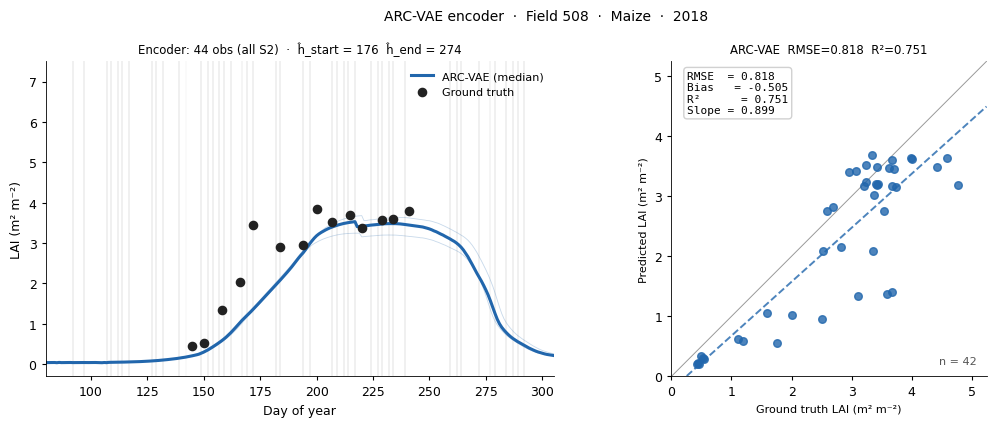

     Saved → /content/drive/MyDrive/01_ARC-VAE/outputs/validation_multifield/enc_only_2018_508.png

  Stage 2 — ARC-KNN  (Yin et al. methodology: ss=155, sl=60, DOY 155–240, library=131,072)
    508_high ...  

Predicting S2 reflectance: 100%|██████████| 300/300 [00:22<00:00, 13.47slice/s]


done (20 obs used)  (103s)
    508_medium ...  

Predicting S2 reflectance: 100%|██████████| 300/300 [00:23<00:00, 12.87slice/s]


done (21 obs used)  (102s)
    508_low ...  

...

6 total obs  (5 in KNN season DOY 155–240)  ĥ_end=278  (2s)
    515_medium ...  STAC search (aws): 27 items found
Filtered to 9 items on tile MGRS-32UQU
Cache: 9/9 items cached, 0 to download


Processing S2 items (aws):   0%|          | 0/9 [00:00<?, ?item/s]

7 total obs  (6 in KNN season DOY 155–240)  ĥ_end=287  (2s)
    515_low ...  STAC search (aws): 27 items found
Filtered to 9 items on tile MGRS-32UQU
Cache: 9/9 items cached, 0 to download


Processing S2 items (aws):   0%|          | 0/9 [00:00<?, ?item/s]

6 total obs  (5 in KNN season DOY 155–240)  ĥ_end=277  (2s)

  ▶ ARC-VAE  2017_515  (n=21 pairs)
     RMSE = 1.315  R² = 0.553  Slope = 0.138  Bias = -0.398


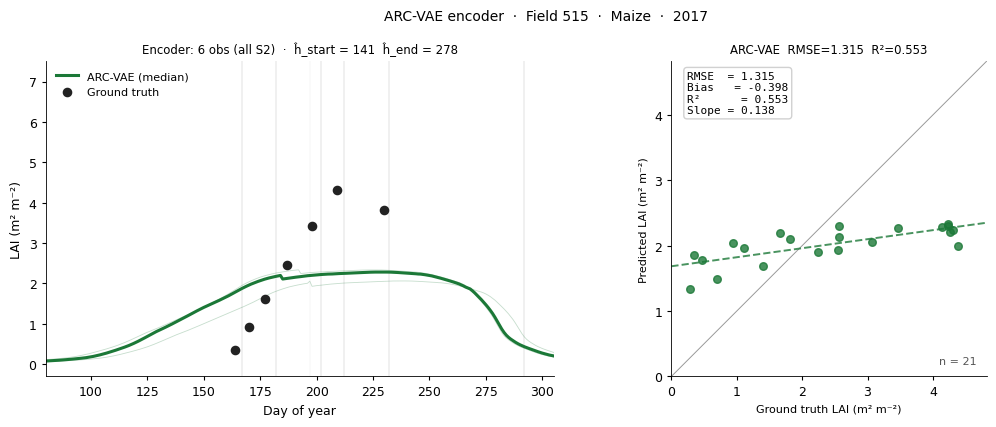

     Saved → /content/drive/MyDrive/01_ARC-VAE/outputs/validation_multifield/enc_only_2017_515.png

  Stage 2 — ARC-KNN  (Yin et al. methodology: ss=155, sl=60, DOY 155–240, library=131,072)
    515_high ...  

Predicting S2 reflectance: 100%|██████████| 300/300 [00:07<00:00, 39.02slice/s]


done (5 obs used)  (84s)
    515_medium ...  

Predicting S2 reflectance: 100%|██████████| 300/300 [00:09<00:00, 32.33slice/s]


done (6 obs used)  (85s)
    515_low ...  

...

9 total obs  (4 in KNN season DOY 155–240)  ĥ_end=252  (2s)
    319_medium ...  STAC search (aws): 18 items found
Filtered to 18 items on tile MGRS-32UPU
Cache: 18/18 items cached, 0 to download


Processing S2 items (aws):   0%|          | 0/18 [00:00<?, ?item/s]

9 total obs  (4 in KNN season DOY 155–240)  ĥ_end=250  (2s)
    319_low ...  STAC search (aws): 18 items found
Filtered to 18 items on tile MGRS-32UPU
Cache: 18/18 items cached, 0 to download


Processing S2 items (aws):   0%|          | 0/18 [00:00<?, ?item/s]

9 total obs  (4 in KNN season DOY 155–240)  ĥ_end=252  (2s)

  ▶ ARC-VAE  2017_319  (n=14 pairs)
     RMSE = 0.978  R² = 0.011  Slope = -0.016  Bias = -0.407


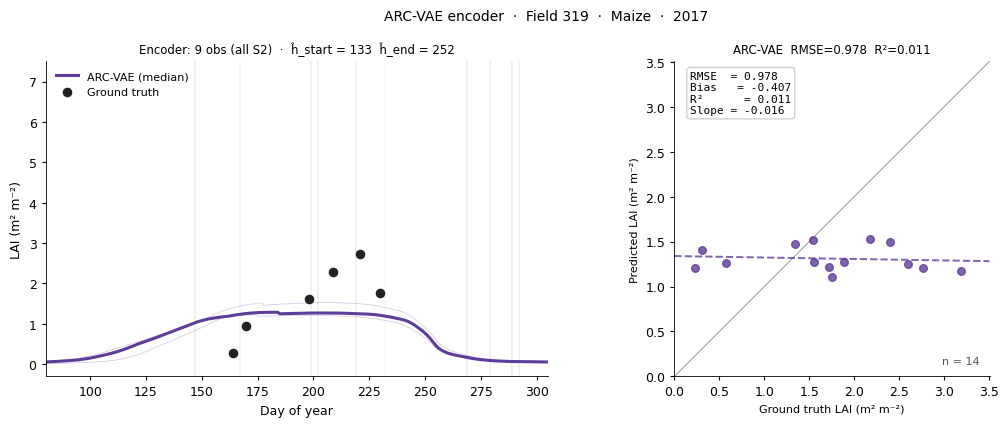

     Saved → /content/drive/MyDrive/01_ARC-VAE/outputs/validation_multifield/enc_only_2017_319.png

  Stage 2 — ARC-KNN  (Yin et al. methodology: ss=155, sl=60, DOY 155–240, library=131,072)
    319_high ...  

Predicting S2 reflectance: 100%|██████████| 300/300 [00:07<00:00, 41.34slice/s]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


done (4 obs used)  (65s)
    319_medium ...  

Predicting S2 reflectance: 100%|██████████| 300/300 [00:04<00:00, 64.70slice/s]


done (4 obs used)  (77s)
    319_low ...  

...

9 total obs  (6 in KNN season DOY 100–230)  ĥ_end=247  (2s)
    301_medium ...  STAC search (aws): 18 items found
Filtered to 18 items on tile MGRS-32UPU
Cache: 18/18 items cached, 0 to download


Processing S2 items (aws):   0%|          | 0/18 [00:00<?, ?item/s]

12 total obs  (8 in KNN season DOY 100–230)  ĥ_end=247  (2s)
    301_low ...  STAC search (aws): 18 items found
Filtered to 18 items on tile MGRS-32UPU
Cache: 18/18 items cached, 0 to download


Processing S2 items (aws):   0%|          | 0/18 [00:00<?, ?item/s]

10 total obs  (7 in KNN season DOY 100–230)  ĥ_end=247  (2s)

  ▶ ARC-VAE  2017_301  (n=19 pairs)
     RMSE = 2.067  R² = 0.028  Slope = -0.032  Bias = -1.740


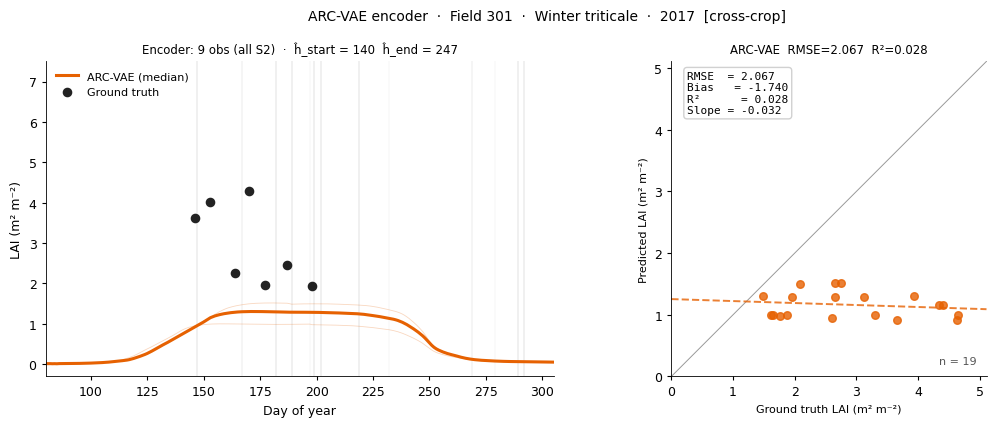

     Saved → /content/drive/MyDrive/01_ARC-VAE/outputs/validation_multifield/enc_only_2017_301.png

  Stage 2 — ARC-KNN  (Yin et al. methodology: ss=100, sl=120, DOY 100–230, library=131,072)
    301_high ...  

Predicting S2 reflectance: 100%|██████████| 300/300 [00:07<00:00, 37.70slice/s]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


done (6 obs used)  (66s)
    301_medium ...  

Predicting S2 reflectance: 100%|██████████| 300/300 [00:08<00:00, 33.54slice/s]


done (8 obs used)  (82s)
    301_low ...  

Predicting S2 reflectance: 100%|██████████| 300/300 [00:09<00:00, 31.82slice/s]


done (7 obs used)  (81s)

  ▶ Comparison  2017_301
     ARC-VAE:  RMSE=2.067  R²=0.028  Slope=-0.032  Bias=-1.740  (n=19)
     ARC-KNN:  RMSE=1.654  R²=0.007  Slope=0.095  Bias=-0.670  (n=19)


All fields done.  Total runtime: 17.3 min

Generating final comparison figures ...


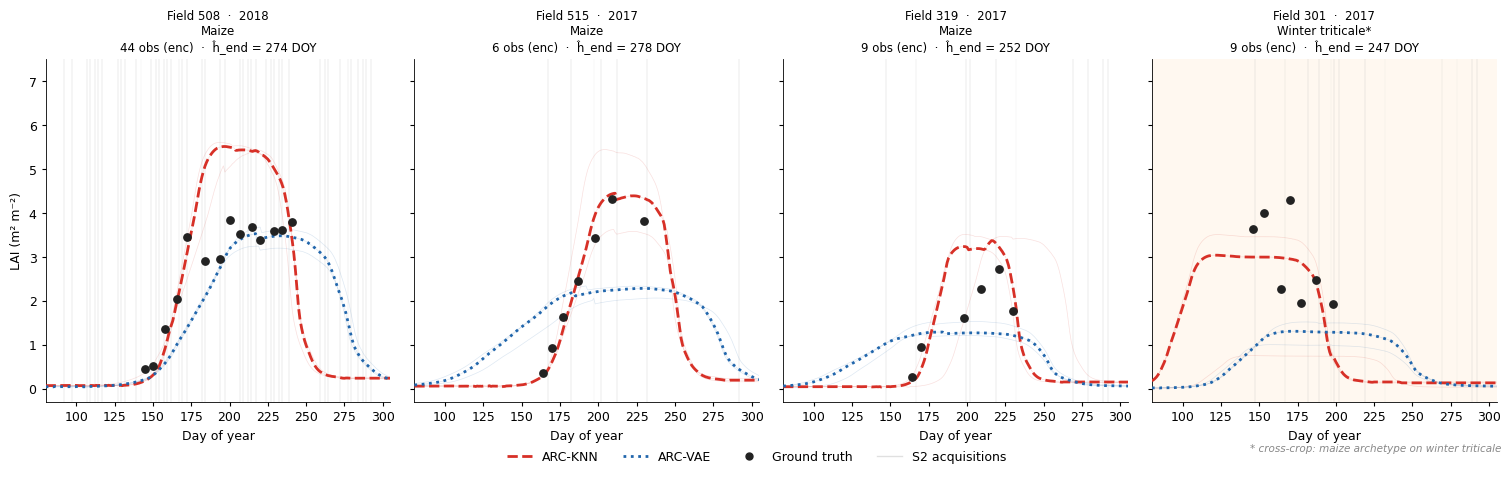

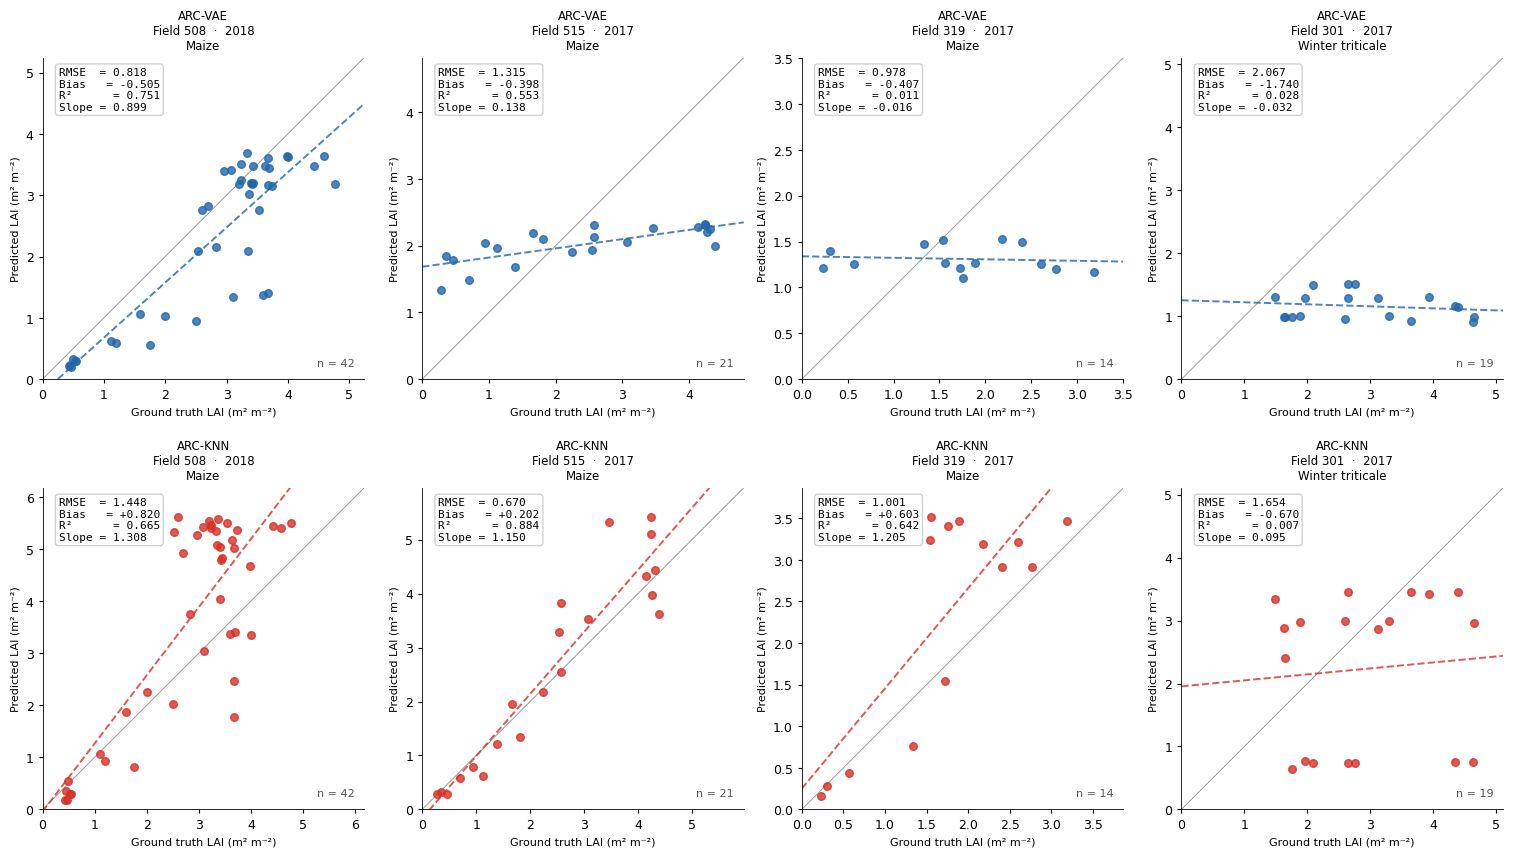


SUMMARY
  KNN methodology: Yin et al. (ss=155, sl=60, growing-season obs only, N_lib=131,072)
     Field                Crop   Enc obs   ĥ_end   ENC RMSE   KNN RMSE   ENC R²   KNN R²   ENC Slp   KNN Slp  n
-----------------------------------------------------------------------------------------------
  2018_508               Maize        44     274      0.818      1.448    0.751    0.665     0.899     1.308  42
  2017_515               Maize         6     278      1.315      0.670    0.553    0.884     0.138     1.150  21
  2017_319               Maize         9     252      0.978      1.001    0.011    0.642    -0.016     1.205  14
  2017_301*   Winter triticale         9     247      2.067      1.654    0.028    0.007    -0.032     0.095  19

  * cross-crop reference: maize archetype on winter triticale

  Note: encoder uses ALL cloud-free S2 observations;
        KNN uses only observations within the growing-season
        window (DOY 155–240) following Yin et al. methodology.

All

In [ ]:
"""
ARC-VAE vs ARC-KNN — multi-field validation, MNI Germany
"""

#Imports and directory definitions as before

import subprocess, sys, warnings
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "https://github.com/MarcYin/ARC/archive/refs/heads/main.zip"],
               check=True)

import os, json, numpy as np, pandas as pd, torch, time
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import pearsonr
import importlib.util
import eof

BASE    = '/content/drive/MyDrive/01_ARC-VAE'
CKPT    = (f'{BASE}/outputs/'
           'maize_d128_L4_e20+30_sup10.0_20260518_1637/checkpoint_best.pt')
OUT_DIR = f'{BASE}/outputs/validation_multifield'
CACHE   = f'{BASE}/LMU_data/S2_cache_coverage'
os.makedirs(OUT_DIR, exist_ok=True)
sys.path.insert(0, f'{BASE}/ARC')
sys.path.insert(0, f'{BASE}/arc_vae')

from encoder import ARCVAEEncoder
from archetype_decoder import ARCDecoder, double_logistic


# knn_ss, knn_sl   : Yin et al. archetype prior parameters
# knn_doy_min/max  : window of observations passed to KNN
#                    (observations outside are EXCLUDED from KNN
#                     but the encoder still sees all of them)
# match_days       : ±N day tolerance for GT matching

FIELDS = {
    '2018_508': {
        'year': 2018, 'crop': 'Maize', 'colour': '#2166ac',
        'cross_crop': False, #indicates whether archetype used (maize here) is same as crop under investigation
        'esus': { #sun coords
            '508_high':   (48.250784, 11.719026),
            '508_medium': (48.249395, 11.719870),
            '508_low':    (48.251360, 11.717283),
        },
        'gt': { #mapping to ground truth measurements
            '508_high':   f'{BASE}/LMU_data/LAI_2018/analysis/508/508 _(MA)_high.txt',
            '508_medium': f'{BASE}/LMU_data/LAI_2018/analysis/508/508 _(MA)_medium.txt',
            '508_low':    f'{BASE}/LMU_data/LAI_2018/analysis/508/508 _(MA)_low.txt',
            '_mean':      f'{BASE}/LMU_data/LAI_2018/analysis/508/508_ (MA)_mean.txt',
        },
        'match_days': 5, #restriction of gap between satellite observation date with ground metric date
        # Yin et al. ss/sl for German maize
        'knn_ss': 155, 'knn_sl': 60,
        # KNN uses only peak-season observations within the archetype window
        'knn_doy_min': 155, 'knn_doy_max': 240,
    },
    '2017_515': {
        'year': 2017, 'crop': 'Maize', 'colour': '#1b7837',
        'cross_crop': False,
        'esus': {
            '515_high':   (48.278194, 11.714955),
            '515_medium': (48.284315, 11.712197),
            '515_low':    (48.281040, 11.714110),
        },
        'gt': {
            '515_high':   f'{BASE}/LMU_data/LAI_2017/data_analysis/515_high.txt',
            '515_medium': f'{BASE}/LMU_data/LAI_2017/data_analysis/515_medium.txt',
            '515_low':    f'{BASE}/LMU_data/LAI_2017/data_analysis/515_low.txt',
            '_mean':      f'{BASE}/LMU_data/LAI_2017/data_analysis/515.txt',
        },
        'match_days': 7,
        # Yin et al. values for Germany Field 515
        'knn_ss': 155, 'knn_sl': 60,
        'knn_doy_min': 155, 'knn_doy_max': 240,
    },
    '2017_319': {
        'year': 2017, 'crop': 'Maize', 'colour': '#5e3c99',
        'cross_crop': False,
        'esus': {
            '319_high':   (48.286526, 11.661576),
            '319_medium': (48.285249, 11.661956),
            '319_low':    (48.285751, 11.660591),
        },
        'gt': {
            '319_high':   f'{BASE}/LMU_data/LAI_2017/data_analysis/319_high.txt',
            '319_medium': f'{BASE}/LMU_data/LAI_2017/data_analysis/319_medium.txt',
            '319_low':    f'{BASE}/LMU_data/LAI_2017/data_analysis/319_low.txt',
            '_mean':      f'{BASE}/LMU_data/LAI_2017/data_analysis/319.txt',
        },
        'match_days': 7,
        'knn_ss': 155, 'knn_sl': 60,
        'knn_doy_min': 155, 'knn_doy_max': 240,
    },
    '2017_301': {
        'year': 2017, 'crop': 'Winter triticale', 'colour': '#e66101',
        'cross_crop': True,   # maize archetype applied to another crop (winter triticale)
        'esus': {
            '301_high':   (48.311267, 11.690094),
            '301_medium': (48.309491, 11.688159),
            '301_low':    (48.309004, 11.690082),
        },
        'gt': {
            '301_high':   f'{BASE}/LMU_data/LAI_2017/data_analysis/301_high.txt',
            '301_medium': f'{BASE}/LMU_data/LAI_2017/data_analysis/301_medium.txt',
            '301_low':    f'{BASE}/LMU_data/LAI_2017/data_analysis/301_low.txt',
            '_mean':      f'{BASE}/LMU_data/LAI_2017/data_analysis/301.txt',
        },
        'match_days': 7,
        # triticale peaks May–June so season starts earlier
        'knn_ss': 100, 'knn_sl': 120,
        'knn_doy_min': 100, 'knn_doy_max': 230,
    },
}

N_LIBRARY = 131072 # Set target parameter density size for baseline Sobol generation steps

# Loading models
encoder = ARCVAEEncoder(d_model=128, n_layers=4, n_heads=4) #initialise encoder
sd      = torch.load(CKPT, map_location='cpu') #load checkpoint metrics
sd      = sd.get('model_state', sd) #get model weights
encoder.load_state_dict(
    {k[len('encoder.'):]: v for k, v in sd.items()
     if k.startswith('encoder.')})
encoder.eval() #freeze for evaluation

decoder = ARCDecoder(crop_type='maize') #initialise ARC with maize archetype
decoder.eval() #non-trainable for evlauation
print(f"Encoder loaded "
      f"({sum(p.numel() for p in encoder.parameters()):,} params)\n")

_spec = importlib.util.spec_from_file_location(
    'arc_sg', f'{BASE}/ARC/arc/arc_sample_generator.py') # load ARC sample generator
_mod  = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_mod)
generate_arc_refs = _mod.generate_arc_refs #generate samples
from arc.approximate_KNN_search import get_neighbours

#Define helper functions:

def load_gt(path, year):
    """Load ground-truth LAI from text file. Returns (N,2) array or None."""
    if not os.path.exists(path):
        return None
    sep = ';' if year == 2017 else ','
    try:
        df   = pd.read_csv(path, sep=sep)
        dcol = next((c for c in df.columns
                     if 'DATE' in c.upper() or 'Date' in c), None)
        lcol = next((c for c in df.columns
                     if 'LAI'  in c.upper()), None)
        if dcol is None or lcol is None:
            return None
        df['DOY'] = pd.to_datetime(df[dcol]).dt.dayofyear
        arr = df[['DOY', lcol]].rename(columns={lcol: 'LAI'}).values
        # remove rows with NaN LAI
        arr = arr[np.isfinite(arr[:, 1])]
        return arr if len(arr) > 0 else None
    except Exception:
        return None


def lai_traj(mu_np, doys):
    """Compute physical LAI from encoder/KNN latent vector at given DOYs."""
    p   = torch.from_numpy(mu_np[:7].astype(np.float32)).unsqueeze(0)
    h   = torch.from_numpy(mu_np[7:].astype(np.float32)).unsqueeze(0)
    d   = torch.tensor(doys, dtype=torch.float32)
    T   = len(doys)
    with torch.no_grad():
        ta  = torch.arange(365, dtype=torch.float32)
        L   = double_logistic(h, ta)
        Lmn = L.amin(1, keepdim=True)
        Lmx = L.amax(1, keepdim=True)
        Ln  = (L - Lmn) / (Lmx - Lmn + 1e-8)
        k1, t1 = h[:, 0:1], h[:, 1:2]
        k2, t2 = h[:, 2:3], h[:, 3:4]
        tp  = (k2 * t1 + k1 * t2) / (k1 + k2 + 1e-8)
        sm  = torch.sigmoid(20 * (ta.unsqueeze(0) - tp))
        Lm  = (1 - sm) * Ln + sm * (2 - Ln)
        idx = (d.long() - 1).clamp(0, 364)
        tau = ARCDecoder._interp1d(
            Lm[:, idx].reshape(-1),
            decoder.v_grid, decoder.doy_grid).reshape(1, T)
        x   = torch.clamp(
            p.unsqueeze(1) * decoder._lookup_meds(tau),
            decoder.lo, decoder.hi)
    return x[0, :, 4].numpy()   # LAI is index 4; extract continuous LAI vector from scaled trait results


def fetch_s2(field_key, esu_name, lat, lon, year):
    """
    Fetch S2 for a 30×30m box centred on (lat, lon).
    Returns deduplicated cloud-free arrays.
    Uses original working indexing: s2.reflectance[:,:,valid].mean(-1)
    which correctly handles the (T, 10, N_pixels) eof array layout.
    """
    dlat = 30 / 111320
    dlon = 30 / (111320 * np.cos(np.radians(lat)))
    coords = [
        [lon - dlon/2, lat - dlat/2],
        [lon + dlon/2, lat - dlat/2],
        [lon + dlon/2, lat + dlat/2],
        [lon - dlon/2, lat + dlat/2],
        [lon - dlon/2, lat - dlat/2],   # close the ring
    ] #Formulate localized bounding box edge vertices coordinates mapping polygon boundaries
    gj = {
        "type": "FeatureCollection",
        "features": [{
            "type": "Feature",
            "properties": {},
            "geometry": {
                "type": "Polygon",
                "coordinates": [coords]
            }
        }]
    } # Package coordinate geometry elements into valid geojson synatx configurations
    gj_path = f'{CACHE}/{field_key}_{esu_name}.geojson'
    with open(gj_path, 'w') as f:
        json.dump(gj, f)

    #get S2 from AWS
    s2 = eof.get_s2_data(
        start_date=f'{year}-04-01',
        end_date=f'{year}-10-20',
        geojson_path=gj_path,
        data_folder=f'{CACHE}/{field_key}_{esu_name}_full',
        source='aws')

    # spatial average over valid (unmasked) pixels
    # s2.reflectance shape: (T, 10, N_pixels) — already flattened
    valid = ~s2.mask
    if not np.any(valid):
        valid = np.ones_like(s2.mask, dtype=bool)   # fallback

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')   # suppress Mean of empty slice
        refl = np.nanmean(s2.reflectance[:, :, valid], axis=-1)  # (T, 10)
        unc  = np.nanmean(s2.uncertainty[:, :, valid], axis=-1)

    angs = s2.angles.T      # (T, 3) — SZA, VZA, RAA
    doys = s2.doys.astype(float)

    # cloud-free: all 10 bands finite and non-negative
    cf = np.isfinite(refl).all(axis=1) & (refl >= 0).all(axis=1)
    refl, unc, angs, doys = refl[cf], unc[cf], angs[cf], doys[cf]

    if len(doys) == 0:
        raise ValueError("No cloud-free observations after filtering")

    # deduplicate same-day observations (S2A + S2B on same calendar day)
    udoys  = np.unique(doys.astype(int))
    refl_u = np.array([refl[doys.astype(int) == d].mean(0) for d in udoys])
    unc_u  = np.array([unc [doys.astype(int) == d].mean(0) for d in udoys])
    angs_u = np.array([angs[doys.astype(int) == d].mean(0) for d in udoys])
    return udoys, refl_u, unc_u, angs_u


def run_encoder(udoys, refl_u, angs_u):
    """Run encoder on ALL available observations."""
    T   = len(udoys)
    MAX = 50
    rp  = np.zeros((1, MAX, 10), np.float32)
    ap  = np.zeros((1, MAX,  3), np.float32)
    dp  = np.zeros((1, MAX),     np.float32)
    mp  = np.zeros((1, MAX),     bool)
    rp[0, :T, :] = refl_u.astype(np.float32)
    ap[0, :T, :] = angs_u.astype(np.float32)
    dp[0, :T]    = udoys.astype(np.float32)
    mp[0, :T]    = True
    with torch.no_grad():
        mu, _ = encoder(
            torch.from_numpy(rp), torch.from_numpy(ap),
            torch.from_numpy(dp), torch.from_numpy(mp))
    return mu[0].numpy()


def run_knn(udoys, refl_u, unc_u, angs_u, ss, sl, doy_min, doy_max):
    """
    Run ARC-KNN following Yin et al. methodology:
      1. Filter observations to growing-season window [doy_min, doy_max].
         Observations outside (bare soil, post-harvest) are excluded because
         the archetype library cannot reproduce soil-dominated spectra and
         the high-dimensional distance metric degrades for large T.
      2. Use crop-calendar ss/sl matching Yin et al. (ss=155, sl=60 for
         German maize) to keep the library prior compact and well-matched.
      3. Filter NaN library entries before distance computation.
      4. Try steps=10 first; fall back to steps=1 if
         get_neighbours raises a NaN error (numerical instability with
         sparse observations during iterative refinement).
    """
    # 1. Filter observations to growing season
    season_mask = (udoys >= doy_min) & (udoys <= doy_max)
    if season_mask.sum() < 2:
        raise ValueError(
            f"Only {season_mask.sum()} obs in growing season "
            f"DOY {doy_min}–{doy_max}. Check knn_doy_min/max.")
    udoys_knn  = udoys[season_mask]
    refl_knn   = refl_u[season_mask]
    unc_knn    = unc_u[season_mask]
    angs_knn   = angs_u[season_mask]
    T          = len(udoys_knn)

    # 2. Generate archetype library
    ANGS = (angs_knn[:, 0], angs_knn[:, 1], angs_knn[:, 2])
    lib, phl, bil, _, _ = generate_arc_refs(
        udoys_knn.astype(int), ss, sl, N_LIBRARY, ANGS, 'maize')

    # 3. Filter NaN library entries
    lib_2d    = lib.reshape(10 * T, -1)          # (10T, N_lib)
    valid_lib = np.isfinite(lib_2d).all(axis=0)
    n_valid   = valid_lib.sum()
    if n_valid < 50:
        raise ValueError(
            f"Only {n_valid} valid library entries after NaN filter. "
            f"Try adjusting knn_ss/knn_sl.")
    lib = lib[:, :, valid_lib]
    bil = bil[valid_lib]
    phl = phl[valid_lib]

    # replace any residual NaN in observations
    refl_knn = np.nan_to_num(refl_knn, nan=0.0)
    unc_knn  = np.nan_to_num(unc_knn,  nan=0.05)

    # 4. KNN search with steps fallback
    refl_T = refl_knn.T[:, :, None]   # (10, T, 1)
    unc_T  = unc_knn.T[:, :, None]

    nn = None
    for steps in [10, 1]:
        try:
            nn = get_neighbours(
                refl_T, unc_T, lib,
                udoys_knn.astype(int), steps=steps, k=100)[0]
            break
        except Exception as e:
            if steps == 1:
                raise RuntimeError(
                    f"get_neighbours failed at steps=1: {e}") from e
            # try steps=1 on next iteration
            continue

    # 5. Weighted posterior estimate
    of   = refl_knn.T.flatten()
    lf   = lib[:, :, nn].reshape(10 * T, len(nn))
    ef   = unc_knn.T.flatten()
    w2   = 1. / (ef[:, None] ** 2 + 1e-12)
    dst  = (w2 * (of[:, None] - lf) ** 2).sum(0)
    w    = dst / (dst.sum() + 1e-12)
    bio  = (w[:, None] * bil[nn]).sum(0)
    pheo = (w[:, None] * phl[nn]).sum(0)
    return np.concatenate([bio, pheo]), int(T)


def build_pairs(gt_data, udoys, mu_enc, mu_knn=None, max_delta=5):
    """Match ground-truth measurements to nearest S2 observation (±max_delta days)."""
    rows = []
    for gt_doy, gt_lai in gt_data:
        if not np.isfinite(gt_lai):
            continue
        closest = udoys[np.argmin(np.abs(udoys - gt_doy))]
        if abs(int(closest) - int(gt_doy)) <= max_delta:
            enc = float(lai_traj(mu_enc, [int(gt_doy)])[0])
            knn = float(lai_traj(mu_knn, [int(gt_doy)])[0]) \
                  if mu_knn is not None else np.nan
            rows.append({
                'gt_doy': int(gt_doy),
                'gt_lai': float(gt_lai),
                'enc_lai': enc,
                'knn_lai': knn,
            })
    return pd.DataFrame(rows) # Return compiled paired coordinates as a structured data table


def calc(obs, pred):
    """Compute RMSE, R², slope, bias. Requires ≥3 paired observations."""
    obs  = np.asarray(obs,  dtype=float)
    pred = np.asarray(pred, dtype=float)
    mask = np.isfinite(obs) & np.isfinite(pred)
    obs, pred = obs[mask], pred[mask]
    n = len(obs)
    if n < 3:
        return dict(rmse=np.nan, r2=np.nan, slope=np.nan, bias=np.nan, n=n)
    rmse  = float(np.sqrt(np.mean((pred - obs) ** 2)))
    r2    = float(pearsonr(obs, pred)[0] ** 2)
    slope = float(np.polyfit(obs, pred, 1)[0])
    bias  = float(np.mean(pred - obs))
    return dict(rmse=rmse, r2=r2, slope=slope, bias=bias, n=n) # Return compiled validation stats dictionary


# plot helpers

#colours and plotting configs
C_ENC = '#2166ac'
C_KNN = '#d73027'
C_GT  = '#222222'
C_S2  = '#cccccc'
DENSE = np.arange(80, 310)

plt.rcParams.update({
    'font.family':      'DejaVu Sans',
    'font.size':        9,
    'font.weight':      'normal',
    'axes.titleweight': 'normal',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.linewidth':   0.6,
    'legend.frameon':   False,
})


def scatter_panel(ax, obs, pred, colour, title):
    """Scatter plot with regression line and metrics annotation."""
    obs  = np.asarray(obs,  dtype=float)
    pred = np.asarray(pred, dtype=float)
    mask = np.isfinite(obs) & np.isfinite(pred)
    obs, pred = obs[mask], pred[mask]
    if len(obs) < 3:
        ax.text(0.5, 0.5, f'n={len(obs)} — insufficient',
                ha='center', va='center', transform=ax.transAxes,
                color='#888', fontsize=9)
        ax.set_title(title, fontsize=8.5)
        return
    vmax = max(obs.max(), pred.max()) * 1.1
    ax.plot([0, vmax], [0, vmax], 'k-', lw=0.7, alpha=0.4)
    ax.scatter(obs, pred, color=colour, s=30, alpha=0.8, zorder=3)
    m, b = np.polyfit(obs, pred, 1)
    xf   = np.linspace(0, vmax, 100)
    ax.plot(xf, m * xf + b, '--', color=colour, lw=1.4, alpha=0.8)
    r2   = pearsonr(obs, pred)[0] ** 2
    rmse = float(np.sqrt(np.mean((pred - obs) ** 2)))
    bias = float(np.mean(pred - obs))
    ax.text(0.05, 0.97,
            f'RMSE  = {rmse:.3f}\nBias   = {bias:+.3f}\n'
            f'R²      = {r2:.3f}\nSlope = {m:.3f}',
            transform=ax.transAxes, fontsize=8, va='top',
            family='monospace',
            bbox=dict(boxstyle='round,pad=0.3',
                      fc='white', ec='#ccc', alpha=0.9))
    ax.text(0.97, 0.04, f'n = {len(obs)}',
            transform=ax.transAxes, fontsize=8, ha='right', color='#555')
    ax.set_xlim(0, vmax); ax.set_ylim(0, vmax)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=8.5)
    ax.set_xlabel('Ground truth LAI (m² m⁻²)', fontsize=8)
    ax.set_ylabel('Predicted LAI (m² m⁻²)',    fontsize=8)


def immediate_figure(field_key, fd, esu_store, pairs_enc):
    """Function to show trajectory and scatter plot straight after encoder runs.
    Allows quicker debugging as ARC-KNN inference is relatively slow."""
    colour = fd['colour']
    cross  = fd.get('cross_crop', False)
    tag    = '  [cross-crop]' if cross else ''
    fig, (ax_t, ax_s) = plt.subplots(1, 2, figsize=(11, 4.3))
    fig.suptitle(
        f"ARC-VAE encoder  ·  Field {field_key.split('_')[1]}"
        f"  ·  {fd['crop']}  ·  {fd['year']}{tag}",
        fontsize=10)

    enc_trajs = []
    for esu_name, ed in esu_store.items():
        et = lai_traj(ed['mu_enc'], DENSE)
        enc_trajs.append(et)
        for d in ed['udoys']:
            ax_t.axvline(d, color=C_S2, lw=0.35, alpha=0.4, zorder=1)
        ax_t.plot(DENSE, et, color=colour, lw=0.6, alpha=0.25)

    ax_t.plot(DENSE, np.median(enc_trajs, 0),
              color=colour, lw=2.2, label='ARC-VAE (median)')

    if len(pairs_enc) > 0:
        gd = pairs_enc.groupby('gt_doy')['gt_lai'].mean()
        ax_t.scatter(gd.index, gd.values,
                     color=C_GT, s=35, zorder=5, label='Ground truth')

    first  = list(esu_store.values())[0]
    h      = first['mu_enc'][7:]
    n_obs  = first['udoys'].shape[0]
    ax_t.set_title(
        f"Encoder: {n_obs} obs (all S2)  ·  "
        f"ĥ_start = {h[1]:.0f}  ĥ_end = {h[3]:.0f}",
        fontsize=8.5)
    ax_t.set_xlabel('Day of year')
    ax_t.set_ylabel('LAI (m² m⁻²)')
    ax_t.set_xlim(80, 305)
    ax_t.set_ylim(-0.3, 7.5)
    ax_t.legend(fontsize=8)

    if len(pairs_enc) >= 3:
        m = calc(pairs_enc['gt_lai'].values, pairs_enc['enc_lai'].values)
        scatter_panel(ax_s,
                      pairs_enc['gt_lai'].values,
                      pairs_enc['enc_lai'].values,
                      colour,
                      f"ARC-VAE  RMSE={m['rmse']:.3f}  R²={m['r2']:.3f}")
    else:
        ax_s.text(0.5, 0.5,
                  f"n={len(pairs_enc)} matched pairs\n"
                  f"(±{fd['match_days']} day window)",
                  ha='center', va='center',
                  transform=ax_s.transAxes, color='#888')

    fig.tight_layout()
    fname = f'{OUT_DIR}/enc_only_{field_key}'
    fig.savefig(f'{fname}.pdf', bbox_inches='tight', dpi=200)
    fig.savefig(f'{fname}.png', bbox_inches='tight', dpi=200)
    plt.show()
    print(f"     Saved → {fname}.png")


#main loop
store  = {}
t_wall = time.time()

for field_key, fd in FIELDS.items():
    year = fd['year']
    cross_tag = '  [cross-crop reference]' if fd.get('cross_crop') else ''
    print(f"  FIELD {field_key}  |  {fd['crop']}  |  {year}{cross_tag}")

    # load ground truth
    gt_all = {}
    for esu_name, gt_path in fd['gt'].items():
        d = load_gt(gt_path, year)
        if d is not None:
            gt_all[esu_name] = d
    if not gt_all:
        print("  No ground truth files found — skipping field")
        continue

    # 1. S2 fetch + encoder
    print("\n S2 fetch + ARC-VAE encoder  (all observations)")
    esu_store = {}

    for esu_name, (lat, lon) in fd['esus'].items():
        print(f"    {esu_name} ...", end='  ', flush=True)
        t0 = time.time()
        try:
            udoys, ru, uu, au = fetch_s2(
                field_key, esu_name, lat, lon, year) # input deduplicated satellite metrics profiles
            mu_enc = run_encoder(udoys, ru, au) #pass observation sequences straight into transformer encoder networks
            esu_store[esu_name] = {
                'udoys': udoys, 'refl': ru, 'unc': uu, 'angs': au,
                'mu_enc': mu_enc, 'mu_knn': None,
            }
            h = mu_enc[7:]
            n_season = int(np.sum(
                (udoys >= fd['knn_doy_min']) & (udoys <= fd['knn_doy_max'])))
            print(f"{len(udoys)} total obs  "
                  f"({n_season} in KNN season DOY "
                  f"{fd['knn_doy_min']}–{fd['knn_doy_max']})  "
                  f"ĥ_end={h[3]:.0f}  ({time.time()-t0:.0f}s)") # Log processing counts, latent outcomes, and speeds metrics
        except Exception as e:
            print(f"ERROR: {e}")

    if not esu_store:
        print("  All ESUs failed — skipping field")
        continue

    # encoder pairs
    enc_rows = []
    for esu_name, ed in esu_store.items():
        _gt = gt_all.get(esu_name)
        gt  = _gt if _gt is not None else gt_all.get('_mean') # fallback to field average data configurations if site records are missing
        if gt is not None: # do pair building routines if verification rows hold valid data
            p = build_pairs(gt, ed['udoys'], ed['mu_enc'],
                            max_delta=fd['match_days'])
            if len(p) > 0:
                p['esu'] = esu_name
                enc_rows.append(p)
    pairs_enc = pd.concat(enc_rows, ignore_index=True) \
                if enc_rows else pd.DataFrame()

    # print encoder results immediately
    print(f"\n  ARC-VAE  {field_key}  (n={len(pairs_enc)} pairs)")
    if len(pairs_enc) >= 3:
        m = calc(pairs_enc['gt_lai'].values, pairs_enc['enc_lai'].values)
        print(f"     RMSE = {m['rmse']:.3f}  R² = {m['r2']:.3f}  "
              f"Slope = {m['slope']:.3f}  Bias = {m['bias']:+.3f}") # Compute RMSE, R², bias, and scaling slope factors
    immediate_figure(field_key, fd, esu_store, pairs_enc)

    store[field_key] = {
        'fd': fd, 'esu_store': esu_store, 'gt_all': gt_all,
        'pairs_enc': pairs_enc, 'pairs_knn': pd.DataFrame(),
    }

    # 2. ARC-KNN
    print(f"\n  ARC-KNN  "
          f"(Yin et al. : ss={fd['knn_ss']}, sl={fd['knn_sl']}, "
          f"DOY {fd['knn_doy_min']}–{fd['knn_doy_max']}, "
          f"library={N_LIBRARY:,})")
    knn_rows = []

    for esu_name, ed in esu_store.items():
        print(f"    {esu_name} ...", end='  ', flush=True)
        t0 = time.time() #start timer
        try:
            mu_knn, n_knn_obs = run_knn(
                ed['udoys'], ed['refl'], ed['unc'], ed['angs'],
                ss=fd['knn_ss'], sl=fd['knn_sl'],
                doy_min=fd['knn_doy_min'], doy_max=fd['knn_doy_max'])
            ed['mu_knn'] = mu_knn
            _gt = gt_all.get(esu_name)
            gt  = _gt if _gt is not None else gt_all.get('_mean')
            if gt is not None:
                p = build_pairs(gt, ed['udoys'], ed['mu_enc'],
                                mu_knn=mu_knn,
                                max_delta=fd['match_days']) # alignment loops to pair satellite snapshots with field visits
                if len(p) > 0:
                    p['esu'] = esu_name
                    knn_rows.append(p)
            print(f"done ({n_knn_obs} obs used)  ({time.time()-t0:.0f}s)")
        except Exception as e:
            print(f"ERROR: {e}")

    pairs_knn = pd.concat(knn_rows, ignore_index=True) \
                if knn_rows else pd.DataFrame()
    store[field_key]['pairs_knn'] = pairs_knn

    if len(pairs_knn) >= 3:
        obs = pairs_knn['gt_lai'].values
        print(f"\n  Comparison  {field_key}")
        for label, pred in [
            ('ARC-VAE', pairs_knn['enc_lai'].values),
            ('ARC-KNN', pairs_knn['knn_lai'].values),
        ]:
            m = calc(obs, pred)
            print(f"     {label}:  RMSE={m['rmse']:.3f}  "
                  f"R²={m['r2']:.3f}  Slope={m['slope']:.3f}  "
                  f"Bias={m['bias']:+.3f}  (n={m['n']})")

print(f"\n\nAll fields done.  "
      f"Total runtime: {(time.time()-t_wall)/60:.1f} min")

# Plotting trajectory comparisons between the two models
fields_done = list(store.keys())
n_f = len(fields_done)

if n_f == 0:
    print("No fields completed successfully — no figures generated.")
else:
    print("\nGenerating final comparison figures ...")

    fig1, axes1 = plt.subplots(1, n_f, figsize=(3.8 * n_f, 4.6),
                                sharey=True)
    if n_f == 1:
        axes1 = [axes1]

    for ax, fk in zip(axes1, fields_done):
        s      = store[fk]
        fd     = s['fd']
        colour = fd['colour']
        cross  = fd.get('cross_crop', False)

        enc_t = []
        knn_t = []
        for esu_name, ed in s['esu_store'].items():
            enc_t.append(lai_traj(ed['mu_enc'], DENSE))
            if ed['mu_knn'] is not None:
                knn_t.append(lai_traj(ed['mu_knn'], DENSE))
            for d in ed['udoys']:
                ax.axvline(d, color=C_S2, lw=0.3, alpha=0.3, zorder=1)

        if enc_t:
            for et in enc_t:
                ax.plot(DENSE, et, color=C_ENC, lw=0.5, alpha=0.15)
            ax.plot(DENSE, np.median(enc_t, 0),
                    color=C_ENC, lw=2.0, ls=':', zorder=4)
        if knn_t:
            for kt in knn_t:
                ax.plot(DENSE, kt, color=C_KNN, lw=0.5, alpha=0.15)
            ax.plot(DENSE, np.median(knn_t, 0),
                    color=C_KNN, lw=2.0, ls='--', zorder=3)

        # ground truth fvalid pairs
        pk = s['pairs_knn'] if len(s['pairs_knn']) > 0 else s['pairs_enc']
        if len(pk) > 0:
            gd = pk.groupby('gt_doy')['gt_lai'].mean()
            ax.scatter(gd.index, gd.values,
                       color=C_GT, s=28, zorder=5)

        first  = list(s['esu_store'].values())[0]
        n_obs  = first['udoys'].shape[0]
        h_end  = f"{first['mu_enc'][7 + 3]:.0f}"
        crop_l = f"{fd['crop']}*" if cross else fd['crop']
        ax.set_title(
            f"Field {fk.split('_')[1]}  ·  {fd['year']}\n"
            f"{crop_l}\n"
            f"{n_obs} obs (enc)  ·  ĥ_end = {h_end} DOY",
            fontsize=8.5)
        ax.set_xlabel('Day of year')
        ax.set_xlim(80, 305)
        ax.set_ylim(-0.3, 7.5)
        if cross:
            ax.patch.set_facecolor('#fff8f0')

    axes1[0].set_ylabel('LAI (m² m⁻²)')
    fig1.legend(handles=[
        Line2D([0],[0], color=C_KNN, lw=2.0, ls='--', label='ARC-KNN'),
        Line2D([0],[0], color=C_ENC, lw=2.0, ls=':',  label='ARC-VAE'),
        Line2D([0],[0], color=C_GT,  lw=0, marker='o', ms=5,
               label='Ground truth'),
        Line2D([0],[0], color=C_S2,  lw=1.0, alpha=0.6,
               label='S2 acquisitions'),
    ], loc='lower center', ncol=4, frameon=False, fontsize=9,
       bbox_to_anchor=(0.5, -0.04))
    if any(store[k]['fd'].get('cross_crop') for k in fields_done):
        fig1.text(0.99, 0.01,
                  '* cross-crop: maize archetype on winter triticale',
                  ha='right', fontsize=7.5, color='#888', style='italic')
    fig1.tight_layout()
    fig1.savefig(f'{OUT_DIR}/fig1_trajectories.pdf',
                 bbox_inches='tight', dpi=200)
    fig1.savefig(f'{OUT_DIR}/fig1_trajectories.png',
                 bbox_inches='tight', dpi=200)
    plt.show()

    # plot final figure
    fig2, axes2 = plt.subplots(2, n_f, figsize=(3.8 * n_f, 8.5))
    if n_f == 1:
        axes2 = axes2.reshape(2, 1)

    for col, fk in enumerate(fields_done):
        s      = store[fk]
        fd     = s['fd']
        colour = fd['colour']
        pk     = s['pairs_knn']
        pe     = s['pairs_enc']
        label  = (f"Field {fk.split('_')[1]}  ·  {fd['year']}\n"
                  f"{fd['crop']}")

        # use KNN pairs if available, otherwise encoder-only
        pairs_use = pk if len(pk) >= 3 else pe

        if len(pairs_use) >= 3:
            obs = pairs_use['gt_lai'].values
            scatter_panel(axes2[0, col],
                          obs, pairs_use['enc_lai'].values,
                          C_ENC, f'ARC-VAE\n{label}')
            if len(pk) >= 3:
                scatter_panel(axes2[1, col],
                              obs, pk['knn_lai'].values,
                              C_KNN, f'ARC-KNN\n{label}')
            else:
                axes2[1, col].axis('off')
                axes2[1, col].text(
                    0.5, 0.5, 'ARC-KNN not available\n(see notes)',
                    ha='center', va='center',
                    transform=axes2[1, col].transAxes,
                    fontsize=9, color='#888')
        else:
            for row in [0, 1]:
                axes2[row, col].axis('off')
                axes2[row, col].text(
                    0.5, 0.5, 'Insufficient pairs',
                    ha='center', va='center',
                    transform=axes2[row, col].transAxes,
                    fontsize=9, color='#888')

    fig2.tight_layout(h_pad=3.0)
    fig2.savefig(f'{OUT_DIR}/fig2_scatter.pdf',
                 bbox_inches='tight', dpi=200)
    fig2.savefig(f'{OUT_DIR}/fig2_scatter.png',
                 bbox_inches='tight', dpi=200)
    plt.show()

    # Metrics summary (RMSE, R^2, slope)
    print("Metrics summary:")
    print(f"  KNN methodology: Yin et al. (ss={list(FIELDS.values())[0]['knn_ss']}, "
          f"sl={list(FIELDS.values())[0]['knn_sl']}, "
          f"growing-season obs only, N_lib={N_LIBRARY:,})")
    print("-" * 95)
    print(f"{'Field':>10}  {'Crop':>18}  {'Enc obs':>8}  {'ĥ_end':>6}  "
          f"{'ENC RMSE':>9}  {'KNN RMSE':>9}  "
          f"{'ENC R²':>7}  {'KNN R²':>7}  "
          f"{'ENC Slp':>8}  {'KNN Slp':>8}  n")
    print("-" * 95)

    for fk in fields_done:
        s   = store[fk]
        fd  = s['fd']
        pk  = s['pairs_knn']
        pe  = s['pairs_enc']
        fe  = list(s['esu_store'].values())[0]
        n_enc = fe['udoys'].shape[0]
        h_end = f"{fe['mu_enc'][7 + 3]:.0f}"
        cross = '*' if fd.get('cross_crop') else ' '

        if len(pk) >= 3:
            obs = pk['gt_lai'].values
            me  = calc(obs, pk['enc_lai'].values)
            mk  = calc(obs, pk['knn_lai'].values)
            print(f"  {fk:>8}{cross} {fd['crop']:>18}  "
                  f"{n_enc:>8}  {h_end:>6}  "
                  f"{me['rmse']:>9.3f}  {mk['rmse']:>9.3f}  "
                  f"{me['r2']:>7.3f}  {mk['r2']:>7.3f}  "
                  f"{me['slope']:>8.3f}  {mk['slope']:>8.3f}  "
                  f"{me['n']}")
        elif len(pe) >= 3:
            obs = pe['gt_lai'].values
            me  = calc(obs, pe['enc_lai'].values)
            print(f"  {fk:>8}{cross} {fd['crop']:>18}  "
                  f"{n_enc:>8}  {h_end:>6}  "
                  f"{me['rmse']:>9.3f}  {'KNN n/a':>9}  "
                  f"{me['r2']:>7.3f}  {'—':>7}  "
                  f"{me['slope']:>8.3f}  {'—':>8}  "
                  f"{me['n']}")
        else:
            print(f"  {fk:>8}{cross} {fd['crop']:>18}  "
                  f"{n_enc:>8}  {h_end:>6}  "
                  f"[no matched pairs — check GT file paths]")

    print("\n  * cross-crop reference: maize archetype on winter triticale")
    print("\n  Note: encoder uses ALL cloud-free S2 observations;")
    print("        KNN uses only observations within the growing-season")
    print(f"        window (DOY {list(FIELDS.values())[0]['knn_doy_min']}–"
          f"{list(FIELDS.values())[0]['knn_doy_max']})")

    # save paired results
    all_pk = []
    for fk in fields_done:
        pk = store[fk]['pairs_knn']
        pe = store[fk]['pairs_enc']
        use = pk if len(pk) > 0 else pe
        if len(use) > 0:
            use = use.copy()
            use['field'] = fk
            all_pk.append(use)
    if all_pk:
        pd.concat(all_pk, ignore_index=True).to_csv(
            f'{OUT_DIR}/all_pairs.csv', index=False)
    print(f"\nAll results saved to {OUT_DIR}/")